<a href="https://colab.research.google.com/github/arturbernardo/eleicoes_fingerprint/blob/main/fingerprint_1994.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from google.colab import drive
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm
pd.options.display.max_columns = None


In [4]:
drive.mount('/content/drive')


Mounted at /content/drive


In [22]:
st = pd.read_csv('/content/drive/MyDrive/data/eleicoes1994/votacao_secao_1994_BR.csv', encoding="ISO-8859-1", sep = ';',
                  dtype={
                          "SG_UF": pd.CategoricalDtype(),
                          "CD_MUNICIPIO": pd.Int64Dtype(),
                          "NR_LOCAL_VOTACAO": pd.Int64Dtype(),
                          "NR_ZONA": pd.Int64Dtype(),
                          "NR_SECAO": pd.CategoricalDtype()
                      })

st


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,CD_CARGO,DS_CARGO,NR_VOTAVEL,NM_VOTAVEL,QT_VOTOS,NR_LOCAL_VOTACAO,SQ_CANDIDATO,NM_LOCAL_VOTACAO,DS_LOCAL_VOTACAO_ENDERECO
0,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,36,CARLOS ANTONIO GOMES,1,-3,10000010100036,#NE,#NE
1,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,56,ENEAS FERREIRA CARNEIRO,25,-3,10000010100056,#NE,#NE
2,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,11,ESPERIDIAO AMIN HELOU FILHO,1,-3,10000010100011,#NE,#NE
3,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE
4,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,20,HERNANI GOULART FORTUNA,1,-3,10000010100020,#NE,#NE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1401803,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,20,HERNANI GOULART FORTUNA,1,-3,27000270100020,#NE,#NE
1401804,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,13,LUIZ INACIO LULA DA SILVA,14,-3,27000270100013,#NE,#NE
1401805,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,15,ORESTES QUERCIA,1,-3,27000270100015,#NE,#NE
1401806,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,95,VOTO BRANCO,7,-3,-1,#NE,#NE


In [74]:
# df_votos = st[st['SG_UF'] == 'AC']
# df_votos
df_votos = st

In [62]:
df_det_rs = pd.read_csv('/content/drive/MyDrive/data/eleicoes1994/detalhe_votacao_secao_1994/detalhe_votacao_secao_1994_BRASIL.csv', encoding="ISO-8859-1", sep = ';',
                  dtype={
                          "SG_UF": pd.CategoricalDtype(),
                          "CD_MUNICIPIO": pd.Int64Dtype(),
                          "NR_LOCAL_VOTACAO": pd.Int64Dtype(),
                          "NR_ZONA": pd.Int64Dtype(),
                          "NR_SECAO": pd.CategoricalDtype()
                      })
df_det_rs


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,CD_CARGO,DS_CARGO,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,QT_VOTOS_NOMINAIS,QT_VOTOS_BRANCOS,QT_VOTOS_NULOS,QT_VOTOS_LEGENDA,QT_VOTOS_ANULADOS_APU_SEP,NR_LOCAL_VOTACAO,NM_LOCAL_VOTACAO,DS_LOCAL_VOTACAO_ENDERECO
0,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1120,ACRELANDIA,8,8,1,PRESIDENTE,332,222,110,161,40,21,0,0,-3,#NE,#NE
1,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,AC,ACRE,1120,ACRELANDIA,8,8,3,GOVERNADOR,332,222,110,145,71,6,0,0,-3,#NE,#NE
2,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,AC,ACRE,1120,ACRELANDIA,8,8,5,SENADOR,332,222,110,286,128,30,0,0,-3,#NE,#NE
3,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,AC,ACRE,1120,ACRELANDIA,8,8,7,DEPUTADO FEDERAL,332,222,110,114,55,35,18,0,-3,#NE,#NE
4,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,AC,ACRE,1120,ACRELANDIA,8,8,8,DEPUTADO ESTADUAL,332,222,110,160,30,27,5,0,-3,#NE,#NE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938158,24/11/2022,15:32:38,1994,2,Eleição Ordinária,2,1994002,Eleições Ordinárias - 1994,15/11/1994,F,SP,SP,SAO PAULO,72451,VOTUPORANGA,147,99,3,GOVERNADOR,481,398,83,349,2,47,0,0,-3,#NE,#NE
938159,24/11/2022,15:32:38,1994,2,Eleição Ordinária,2,1994002,Eleições Ordinárias - 1994,15/11/1994,F,SP,SP,SAO PAULO,72451,VOTUPORANGA,147,100,3,GOVERNADOR,539,452,87,387,9,56,0,0,-3,#NE,#NE
938160,24/11/2022,15:32:38,1994,2,Eleição Ordinária,2,1994002,Eleições Ordinárias - 1994,15/11/1994,F,SP,SP,SAO PAULO,61921,ZACARIAS,214,21,3,GOVERNADOR,426,318,108,288,3,27,0,0,-3,#NE,#NE
938161,24/11/2022,15:32:38,1994,2,Eleição Ordinária,2,1994002,Eleições Ordinárias - 1994,15/11/1994,F,SP,SP,SAO PAULO,61921,ZACARIAS,214,22,3,GOVERNADOR,448,372,76,342,4,26,0,0,-3,#NE,#NE


In [75]:
df_rs_president = df_votos[df_votos['DS_CARGO'] == 'PRESIDENTE']
df_rs_president = df_rs_president[df_rs_president['NR_VOTAVEL'] == 45]
merged = df_rs_president.merge(df_det_rs, on=['SG_UF', 'CD_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])
merged

,DT_GERACAO_x,HH_GERACAO_x,ANO_ELEICAO_x,CD_TIPO_ELEICAO_x,NM_TIPO_ELEICAO_x,NR_TURNO_x,CD_ELEICAO_x,DS_ELEICAO_x,DT_ELEICAO_x,TP_ABRANGENCIA_x,SG_UF,SG_UE_x,NM_UE_x,CD_MUNICIPIO,NM_MUNICIPIO_x,NR_ZONA,NR_SECAO,CD_CARGO_x,DS_CARGO_x,NR_VOTAVEL,NM_VOTAVEL,QT_VOTOS,NR_LOCAL_VOTACAO_x,SQ_CANDIDATO,NM_LOCAL_VOTACAO_x,DS_LOCAL_VOTACAO_ENDERECO_x,DT_GERACAO_y,HH_GERACAO_y,ANO_ELEICAO_y,CD_TIPO_ELEICAO_y,NM_TIPO_ELEICAO_y,NR_TURNO_y,CD_ELEICAO_y,DS_ELEICAO_y,DT_ELEICAO_y,TP_ABRANGENCIA_y,SG_UE_y,NM_UE_y,NM_MUNICIPIO_y,CD_CARGO_y,DS_CARGO_y,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,QT_VOTOS_NOMINAIS,QT_VOTOS_BRANCOS,QT_VOTOS_NULOS,QT_VOTOS_LEGENDA,QT_VOTOS_ANULADOS_APU_SEP,NR_LOCAL_VOTACAO_y,NM_LOCAL_VOTACAO_y,DS_LOCAL_VOTACAO_ENDERECO_y
0,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,BR,BRASIL,RIO BRANCO,1,PRESIDENTE,357,268,89,245,13,10,0,0,-3,#NE,#NE
1,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,3,GOVERNADOR,357,268,89,238,23,7,0,0,-3,#NE,#NE
2,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,5,SENADOR,357,268,89,427,81,28,0,0,-3,#NE,#NE
3,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,7,DEPUTADO FEDERAL,357,268,89,203,27,34,4,0,-3,#NE,#NE
4,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,8,DEPUTADO ESTADUAL,357,268,89,233,15,19,1,0,-3,#NE,#NE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937775,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,40,-3,27000270100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,BR,BRASIL,ARAGUANA,1,PRESIDENTE,115,76,39,58,7,11,0,0,-3,#NE,#NE
937776,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,40,-3,27000270100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,TOCANTINS,ARAGUANA,3,GOVERNADOR,115,76,39,57,15,4,0,0,-3,#NE,#NE
937777,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,BRASIL,73318,ARAGUANA,34,40,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,40,-3,27000270100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,TOCANTINS,ARAGUANA,5,SENADOR,115,76,39,106,42,4,0,0,-3,#NE,#NE
937778,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,TO,BR,

In [65]:
merged.columns

Index(['DT_GERACAO_x', 'HH_GERACAO_x', 'ANO_ELEICAO_x', 'CD_TIPO_ELEICAO_x',
       'NM_TIPO_ELEICAO_x', 'NR_TURNO_x', 'CD_ELEICAO_x', 'DS_ELEICAO_x',
       'DT_ELEICAO_x', 'TP_ABRANGENCIA_x', 'SG_UF', 'SG_UE_x', 'NM_UE_x',
       'CD_MUNICIPIO', 'NM_MUNICIPIO_x', 'NR_ZONA', 'NR_SECAO', 'CD_CARGO_x',
       'DS_CARGO_x', 'NR_VOTAVEL', 'NM_VOTAVEL', 'QT_VOTOS',
       'NR_LOCAL_VOTACAO_x', 'SQ_CANDIDATO', 'NM_LOCAL_VOTACAO_x',
       'DS_LOCAL_VOTACAO_ENDERECO_x', 'DT_GERACAO_y', 'HH_GERACAO_y',
       'ANO_ELEICAO_y', 'CD_TIPO_ELEICAO_y', 'NM_TIPO_ELEICAO_y', 'NR_TURNO_y',
       'CD_ELEICAO_y', 'DS_ELEICAO_y', 'DT_ELEICAO_y', 'TP_ABRANGENCIA_y',
       'SG_UE_y', 'NM_UE_y', 'NM_MUNICIPIO_y', 'CD_CARGO_y', 'DS_CARGO_y',
       'QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS',
       'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS', 'QT_VOTOS_LEGENDA',
       'QT_VOTOS_ANULADOS_APU_SEP', 'NR_LOCAL_VOTACAO_y', 'NM_LOCAL_VOTACAO_y',
       'DS_LOCAL_VOTACAO_ENDERECO_y'],
      d

In [76]:
merged['winner_votes'] = merged['QT_VOTOS'] # QT_VOTOS_NOMINAIS?
merged['turnout_pct'] = merged['QT_COMPARECIMENTO'] / merged['QT_APTOS'] * 100
merged["valid_votes_2cand"] = merged["QT_COMPARECIMENTO"]


In [70]:
merged

,DT_GERACAO_x,HH_GERACAO_x,ANO_ELEICAO_x,CD_TIPO_ELEICAO_x,NM_TIPO_ELEICAO_x,NR_TURNO_x,CD_ELEICAO_x,DS_ELEICAO_x,DT_ELEICAO_x,TP_ABRANGENCIA_x,SG_UF,SG_UE_x,NM_UE_x,CD_MUNICIPIO,NM_MUNICIPIO_x,NR_ZONA,NR_SECAO,CD_CARGO_x,DS_CARGO_x,NR_VOTAVEL,NM_VOTAVEL,QT_VOTOS,NR_LOCAL_VOTACAO_x,SQ_CANDIDATO,NM_LOCAL_VOTACAO_x,DS_LOCAL_VOTACAO_ENDERECO_x,DT_GERACAO_y,HH_GERACAO_y,ANO_ELEICAO_y,CD_TIPO_ELEICAO_y,NM_TIPO_ELEICAO_y,NR_TURNO_y,CD_ELEICAO_y,DS_ELEICAO_y,DT_ELEICAO_y,TP_ABRANGENCIA_y,SG_UE_y,NM_UE_y,NM_MUNICIPIO_y,CD_CARGO_y,DS_CARGO_y,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,QT_VOTOS_NOMINAIS,QT_VOTOS_BRANCOS,QT_VOTOS_NULOS,QT_VOTOS_LEGENDA,QT_VOTOS_ANULADOS_APU_SEP,NR_LOCAL_VOTACAO_y,NM_LOCAL_VOTACAO_y,DS_LOCAL_VOTACAO_ENDERECO_y,winner_pct,turnout_pct,valid_votes_2cand
0,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,BR,BRASIL,RIO BRANCO,1,PRESIDENTE,357,268,89,245,13,10,0,0,-3,#NE,#NE,137,75.070028,268
1,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,3,GOVERNADOR,357,268,89,238,23,7,0,0,-3,#NE,#NE,137,75.070028,268
2,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,5,SENADOR,357,268,89,427,81,28,0,0,-3,#NE,#NE,137,75.070028,268
3,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,7,DEPUTADO FEDERAL,357,268,89,203,27,34,4,0,-3,#NE,#NE,137,75.070028,268
4,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1392,RIO BRANCO,1,1,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,137,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,RIO BRANCO,8,DEPUTADO ESTADUAL,357,268,89,233,15,19,1,0,-3,#NE,#NE,137,75.070028,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4975,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1538,SENADOR GUIOMARD,8,98,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,55,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,SENADOR GUIOMARD,3,GOVERNADOR,150,141,9,118,18,5,0,0,-3,#NE,#NE,55,94.000000,141
4976,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1538,SENADOR GUIOMARD,8,98,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,55,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,ACRE,SENADOR GUIOMARD,5,SENADOR,150,141,9,191,76,15,0,0,-3,#NE,#NE,55,94.000000,141
4977,24/11/2022,08:52:41,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinárias - 1994,03/10/1994,F,AC,BR,BRASIL,1538,SENADOR GUIOMARD,8,98,1,PRESIDENTE,45,FERNANDO HENRIQUE CARDOSO,55,-3,10000010100045,#NE,#NE,24/11/2022,15:32:38,1994,2,Eleição Ordinária,1,1994001,Eleições Ordinár

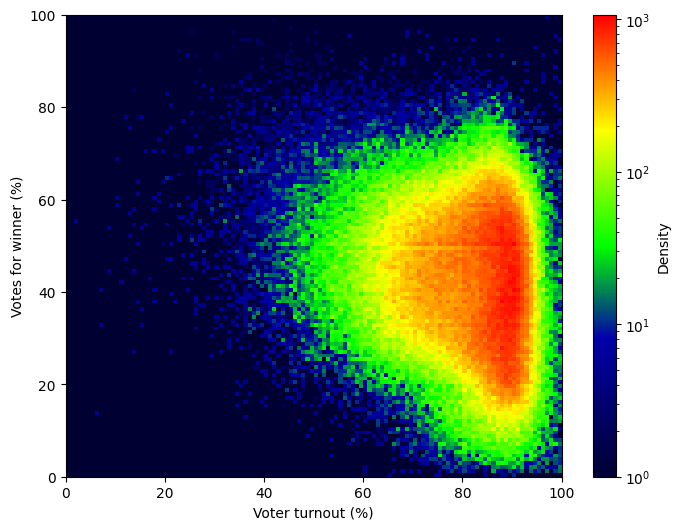

In [77]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

colors = [
    (0.0, "#000033"),   # azul escuro (fundo)
    (0.3, "#0000AA"),   # azul
    (0.5, "#00FF00"),   # verde
    (0.75, "#FFFF00"),  # amarelo (transição)
    (1.0, "#FF0000")    # vermelho
]

cmap = LinearSegmentedColormap.from_list("blue_green_red", colors)


fingerprint_df = merged.rename(columns={
    "QT_APTOS": "registered_voters",
    "QT_COMPARECIMENTO": "ballots_cast",
    "valid_votes_2cand": "valid_votes",
    "winner_votes": "winner_votes"
})[["registered_voters", "ballots_cast", "valid_votes", "winner_votes"]].copy()

fingerprint_df["turnout_pct"] = (
    fingerprint_df["ballots_cast"] / fingerprint_df["registered_voters"] * 100
)

fingerprint_df["winner_pct"] = (
    fingerprint_df["winner_votes"] / fingerprint_df["valid_votes"] * 100
)

fingerprint_df = fingerprint_df[
    (fingerprint_df["registered_voters"] > 0) &
    (fingerprint_df["valid_votes"] > 0)
].copy()

plt.figure(figsize=(8, 6))
plt.hist2d(
    fingerprint_df["turnout_pct"],
    fingerprint_df["winner_pct"],
    bins=120,
    range=[[0, 100], [0, 100]],
    cmap=cmap,
    norm=LogNorm()
)
plt.colorbar(label="Density")
plt.xlabel("Voter turnout (%)")
plt.ylabel("Votes for winner (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.gca().set_facecolor("#000033")

plt.show()